In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.signal import detrend
from scipy.stats import binned_statistic

In [2]:
data_dir = "/Users/zoecas/Documents/data/"
ds = xr.open_dataset(data_dir+"SWOT_L2_LR_SSH_Basic_045_216_20260131T225821_20260131T234949_PID0_01.nc")
ds

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-02-02T16:31:42Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       58.654631510607544
    ssha_variance:                                 2.220821713141298
    references:                                    V1.4.1
    equator_longitude:                             -83.03

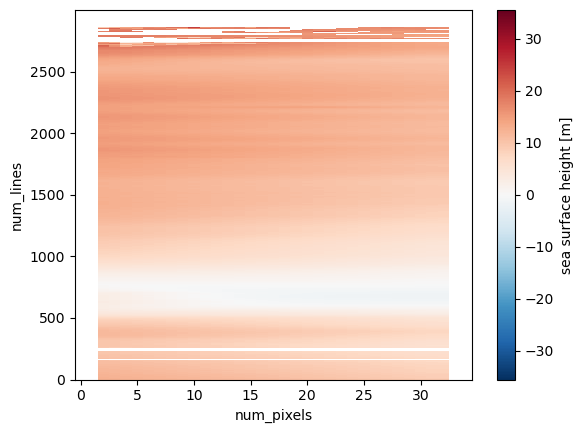

In [8]:
ds.ssh_karin.sel(num_lines=slice(4600,7600),num_pixels=slice(0,35)).plot()


In [9]:
ds = ds.sel(num_lines=slice(4600,7600),num_pixels=slice(0,35))

In [10]:
ssh = ds["ssh_karin"]#.values
lat = ds["latitude"]#.values
lon = ds["longitude"]#.values

In [11]:
R = 6371.0

lat0 = np.nanmean(lat)
lon0 = np.nanmean(lon)

x = (
    np.deg2rad(lon - lon0)
    * np.cos(np.deg2rad(lat0))
    * R
)

y = np.deg2rad(lat - lat0) * R

In [12]:
#mask = np.isfinite(ssh)

#ssh = np.where(mask, ssh, np.nan)

In [13]:
ssh = xr.DataArray(ssh.values,dims=["along_track", "cross_track"]
                  ).interpolate_na(dim="cross_track",method="linear"
                   ).interpolate_na(dim="along_track",method="linear")

In [14]:
ssh = ssh.where(np.isnan(ssh)==False,drop=True)


In [15]:
ssh

<xarray.DataArray (along_track: 2859, cross_track: 31)> Size: 709kB
array([[12.6526, 12.572 , 12.4615, ...,  9.5989,  9.522 ,  9.4886],
       [12.6297, 12.5481, 12.4451, ...,  9.5394,  9.4669,  9.4403],
       [12.6058, 12.5447, 12.4385, ...,  9.4624,  9.3906,  9.366 ],
       ...,
       [25.6411, 19.476 , 16.2904, ..., 16.978 , 16.98  , 16.5184],
       [ 9.0944, 11.8386, 13.9756, ..., 16.878 , 16.7349, 16.4525],
       [11.9459, 14.2299, 13.8517, ..., 16.818 , 16.5432, 16.3143]],
      shape=(2859, 31))
Dimensions without coordinates: along_track, cross_track

In [16]:
_ssh = detrend(
    ssh.fillna(0),
    axis=0,
    type="linear"
)

_ssh = detrend(
    _ssh,
    axis=1,
    type="linear"
)

In [17]:
_ssh

array([[ 2.29775057e-02, -1.29891568e-02, -7.58193333e-02, ...,
        -1.32563819e-01, -1.56807750e-01, -1.76855871e-01],
       [ 2.10851928e-02, -1.37391534e-02, -6.68912124e-02, ...,
        -1.11931014e-01, -1.29644007e-01, -1.40770730e-01],
       [ 2.75900729e-06, -1.09029404e-02, -6.38005511e-02, ...,
        -9.12510724e-02, -1.04856796e-01, -1.10585790e-01],
       ...,
       [ 7.73613174e+00,  1.63804642e+00, -1.37525362e+00, ...,
         1.42461233e-01,  1.87003392e-01, -2.98603827e-01],
       [-7.17203698e+00, -4.44824866e+00, -2.22633925e+00, ...,
        -7.67805116e-01, -9.55800688e-01, -1.34965518e+00],
       [-5.80364825e+00, -3.47351462e+00, -3.70022411e+00, ...,
        -4.48507714e-01, -7.01669364e-01, -9.75499471e-01]],
      shape=(2859, 31))

In [18]:
dx = 2.0
dy = 2.0

In [34]:
L_along = 256.0
L_cross = 40.0

nx = int(L_along/dx)
ny = int(L_cross/dy)

In [35]:
i0 = 1000
j0 = 10

patch = _ssh[
    i0:i0+nx,
    j0:j0+ny
]

In [36]:
patch

array([[ 0.0634373 ,  0.06827356,  0.0628754 , ..., -0.05421988,
        -0.06631955, -0.07465512],
       [ 0.06372594,  0.07197618,  0.06990374, ..., -0.05380801,
        -0.06575465, -0.06811041],
       [ 0.05517064,  0.07240879,  0.06333604, ..., -0.04808291,
        -0.05860257, -0.07140457],
       ...,
       [ 0.02813715,  0.04120357,  0.04680529, ..., -0.02178953,
        -0.02277679, -0.01235224],
       [ 0.03020786,  0.04870732,  0.04295383, ..., -0.02297136,
        -0.02778652, -0.0100631 ],
       [ 0.032983  ,  0.04600106,  0.03357794, ..., -0.01849417,
        -0.02515166, -0.01494379]], shape=(128, 20))

In [37]:
wx = np.hanning(nx)
wy = np.hanning(ny)

window = np.outer(wx, wy)

patch = patch * window

In [39]:
F = np.fft.fft2(patch)

E2d = np.abs(F)**2


In [43]:
kx = np.fft.fftfreq(nx, dx)
ky = np.fft.fftfreq(ny, dy)

KX, KY = np.meshgrid(kx,ky,indexing="ij")

In [45]:
along_sector = (np.abs(KY)<0.5*np.abs(KX))

cross_sector = (np.abs(KX)<0.5*np.abs(KY))

In [46]:
E_along = np.nanmean(E2d[along_sector])

E_cross = np.nanmean(E2d[cross_sector])

anisotropy = E_along / E_cross

In [48]:
anisotropy

np.float64(0.10761753568766522)

In [ ]:
for i0 in range(0,n_along-nx,nx//2):
    for j0 in range(0,n_cross-ny,ny//2):

In [ ]:
E_mean = np.nanmean(all_spectra,axis=0)

A_mean = np.nanmean(all_anisotropy,axis=0)